In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report

In [2]:
cols = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes',
    'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
    'num_compromised','root_shell','su_attempted','num_root',
    'num_file_creations','num_shells','num_access_files','num_outbound_cmds',
    'is_host_login','is_guest_login','count','srv_count','serror_rate',
    'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate',
    'diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate','label','difficulty'
]
df = pd.read_csv('KDDTrain+_20Percent.txt', header=None, names=cols)

In [3]:
for col in ['protocol_type','service','flag']:
    df[col] = LabelEncoder().fit_transform(df[col])

In [4]:
df['is_attack'] = (df['label'] != 'normal').astype(int)

In [5]:
X = df.drop(columns=['label','difficulty','is_attack'])
y = df['is_attack']

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
iso = IsolationForest(contamination=0.1, random_state=42, n_jobs=-1)
iso.fit(X_scaled)
scores = iso.decision_function(X_scaled)
preds  = iso.predict(X_scaled)
y_pred = (preds == -1).astype(int)   # -1 = anomaly = attack

In [8]:
print(classification_report(y, y_pred, target_names=['Normal','Attack']))

              precision    recall  f1-score   support

      Normal       0.55      0.93      0.69     13449
      Attack       0.63      0.13      0.22     11743

    accuracy                           0.56     25192
   macro avg       0.59      0.53      0.46     25192
weighted avg       0.59      0.56      0.47     25192



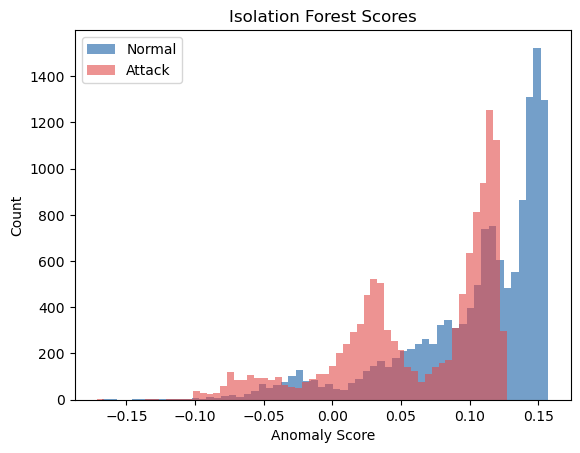

In [9]:
plt.hist(scores[y==0], bins=60, alpha=0.6, label='Normal',  color='#185FA5')
plt.hist(scores[y==1], bins=60, alpha=0.6, label='Attack',  color='#E24B4A')
plt.xlabel("Anomaly Score"); plt.ylabel("Count")
plt.title("Isolation Forest Scores"); plt.legend(); plt.show()

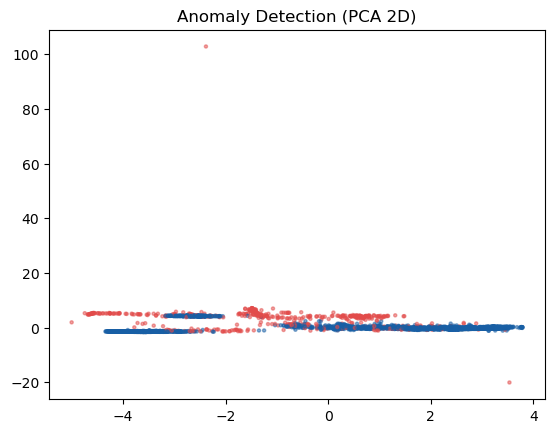

In [10]:
X_2d = PCA(n_components=2).fit_transform(X_scaled[:5000])
c = ['#185FA5' if p==0 else '#E24B4A' for p in y_pred[:5000]]
plt.scatter(X_2d[:,0], X_2d[:,1], c=c, s=5, alpha=0.5)
plt.title("Anomaly Detection (PCA 2D)"); plt.show()